# Comparaison MLP — Cas de tests du prof

Ce notebook reprend **les données exactes** des cas de tests du prof et y branche
**mon MLP** (Rust). Pour chaque cas : à **gauche** la vérité, à **droite** la
prédiction du MLP.

**Hyperparamètres modifiables** en haut de chaque cellule : `STEPS`, `LR`, `ARCH`,
et maintenant **`ACTIV`** = la fonction d'activation des couches cachées
(`"tanh"`, `"sigmoid"` ou `"relu"`).

La dernière section **compare les 3 activations** côte à côte (pour le rapport).


In [12]:
import sys, os                                              # modules systeme (chemins)
sys.path.insert(0, os.path.join(os.getcwd(), "..", "python"))  # rendre bindings.py trouvable

import numpy as np                     # tableaux
import matplotlib.pyplot as plt        # graphiques
from mpl_toolkits.mplot3d import Axes3D # affichage 3D
from bindings import MLP               # MA classe MLP (appelle le Rust)

PALETTE = np.array(["#1f77b4", "#d62728", "#2ca02c"])  # bleu / rouge / vert


def _classes(sorties, n_out):
    # sorties du MLP -> numero de classe
    sorties = np.asarray(sorties)
    if n_out == 1:
        return (sorties[:, 0] >= 0).astype(int)      # 1 sortie : signe
    return np.argmax(sorties, axis=1)                # multi : plus grande sortie


def _dessine_frontiere(ax, mlp, X, cls_vraie, n_out, titre):
    # dessine le fond (frontiere de decision) + les points, sur l'axe ax
    x0min, x0max = X[:, 0].min() - 0.2, X[:, 0].max() + 0.2
    x1min, x1max = X[:, 1].min() - 0.2, X[:, 1].max() + 0.2
    gx, gy = np.meshgrid(np.linspace(x0min, x0max, 100),
                         np.linspace(x1min, x1max, 100))
    cls_grille = _classes([mlp.predict([a, b]) for a, b in zip(gx.ravel(), gy.ravel())], n_out)
    ax.scatter(gx.ravel(), gy.ravel(), c=PALETTE[cls_grille], s=6, alpha=0.25)  # fond
    ax.scatter(X[:, 0], X[:, 1], c=PALETTE[cls_vraie], edgecolor="k", s=25)     # points
    ax.set_title(titre)


def montre_classif(X, Y, arch, steps, lr, titre, activation="tanh"):
    # Entraine un MLP de classification et compare verite vs prediction
    X = np.asarray(X, float); Y = np.asarray(Y, float)
    if Y.ndim == 1: Y = Y.reshape(-1, 1)
    n_out = arch[-1]
    cls_vraie = (Y[:, 0] >= 0).astype(int) if n_out == 1 else np.argmax(Y, axis=1)

    mlp = MLP(arch, activation=activation)                          # <-- activation choisie ici
    mlp.fit(X, Y, steps=steps, lr=lr, is_classification=True)

    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    ax[0].scatter(X[:, 0], X[:, 1], c=PALETTE[cls_vraie], edgecolor="k", s=25)
    ax[0].set_title("Donnees reelles — " + titre)
    _dessine_frontiere(ax[1], mlp, X, cls_vraie, n_out, "Prediction MLP " + str(arch))

    acc = 100.0 * np.mean(_classes([mlp.predict(x) for x in X], n_out) == cls_vraie)
    fig.suptitle(f"{titre}  —  activation={activation}  —  precision = {acc:.1f}%   (STEPS={steps}, LR={lr})")
    plt.tight_layout(); plt.show()


def montre_reg(X, Y, arch, steps, lr, titre, activation="tanh"):
    # Entraine un MLP de REGRESSION (sortie lineaire) et compare reel vs predit
    X = np.asarray(X, float); Y = np.asarray(Y, float)
    if Y.ndim == 1: Y = Y.reshape(-1, 1)
    mlp = MLP(arch, activation=activation)
    mlp.fit(X, Y, steps=steps, lr=lr, is_classification=False)
    pred = np.array([mlp.predict(x, is_classification=False)[0] for x in X])
    mse = float(np.mean((pred - Y[:, 0]) ** 2))
    if X.shape[1] == 1:
        xs = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
        ys = [mlp.predict([x], is_classification=False)[0] for x in xs]
        plt.figure(figsize=(6, 4))
        plt.scatter(X[:, 0], Y[:, 0], color="blue", label="reel")
        plt.plot(xs, ys, color="red", label="MLP"); plt.legend()
    else:
        fig = plt.figure(figsize=(6.5, 5)); ax = fig.add_subplot(111, projection="3d")
        ax.scatter(X[:, 0], X[:, 1], Y[:, 0], color="blue", label="reel")
        ax.scatter(X[:, 0], X[:, 1], pred, color="red", label="MLP"); ax.legend()
    plt.title(f"{titre} {arch}  —  activation={activation}  —  MSE = {mse:.4f}")
    plt.show()


def compare_activations(X, Y, arch, steps, lr, titre):
    # Entraine le MEME cas avec tanh / sigmoid / relu et affiche les 3 cote a cote
    X = np.asarray(X, float); Y = np.asarray(Y, float)
    if Y.ndim == 1: Y = Y.reshape(-1, 1)
    n_out = arch[-1]
    cls_vraie = (Y[:, 0] >= 0).astype(int) if n_out == 1 else np.argmax(Y, axis=1)

    activations = ["tanh", "sigmoid", "relu"]
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
    for k, a in enumerate(activations):
        mlp = MLP(arch, activation=a)
        mlp.fit(X, Y, steps=steps, lr=lr, is_classification=True)
        acc = 100.0 * np.mean(_classes([mlp.predict(x) for x in X], n_out) == cls_vraie)
        _dessine_frontiere(ax[k], mlp, X, cls_vraie, n_out, f"{a}  —  {acc:.0f}%")
    fig.suptitle(f"Comparaison des activations sur : {titre}  {arch}   (STEPS={steps}, LR={lr})")
    plt.tight_layout(); plt.show()


## Classification

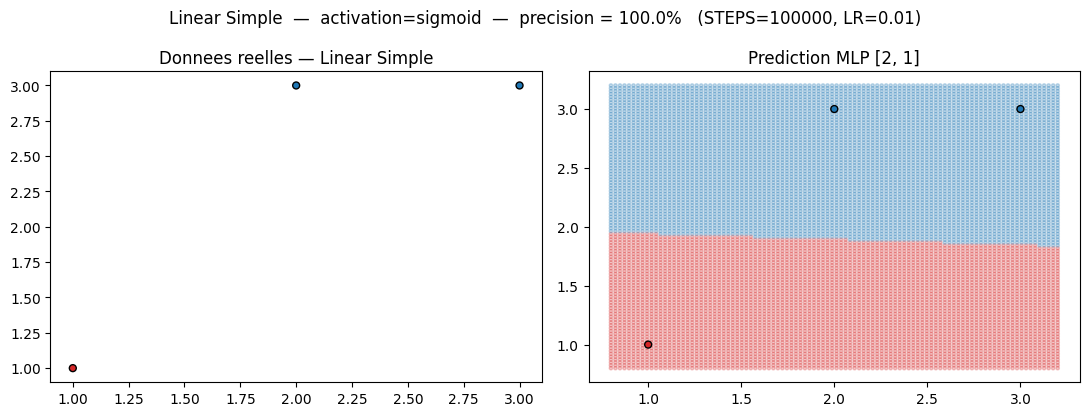

In [13]:
# ---- Linear Simple ----  (Linear: OK / MLP (2,1): OK)
STEPS, LR, ARCH, ACTIV = 100_000, 0.01, [2, 1], "sigmoid"   # ACTIV : "tanh" | "sigmoid" | "relu"
X = np.array([[1, 1], [2, 3], [3, 3]])
Y = np.array([1, -1, -1])
montre_classif(X, Y, ARCH, STEPS, LR, "Linear Simple", activation=ACTIV)

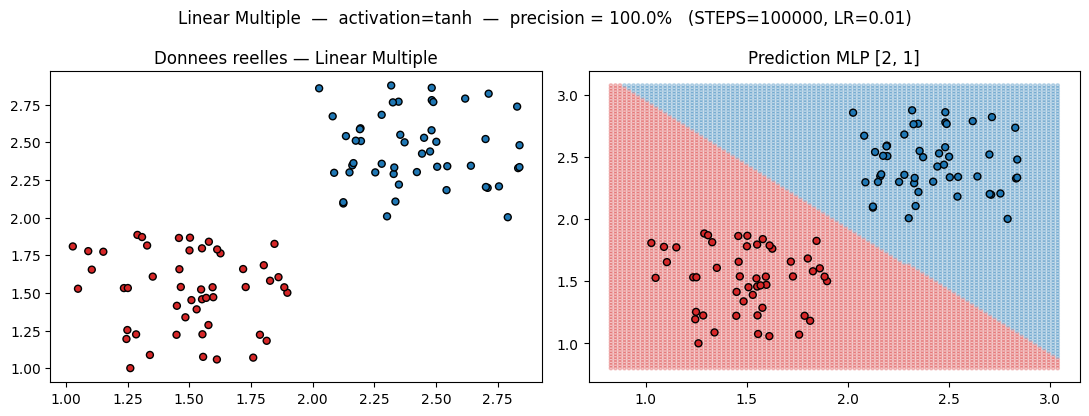

In [14]:
# ---- Linear Multiple ----  (Linear: OK / MLP (2,1): OK)
STEPS, LR, ARCH, ACTIV = 100_000, 0.01, [2, 1], "tanh"
X = np.concatenate([np.random.random((50, 2)) * 0.9 + np.array([1, 1]),
                    np.random.random((50, 2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])
montre_classif(X, Y, ARCH, STEPS, LR, "Linear Multiple", activation=ACTIV)

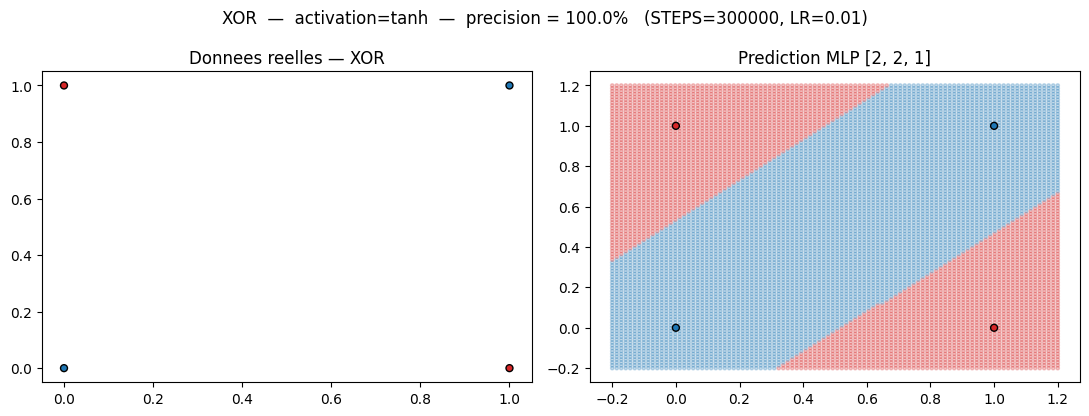

In [15]:
# ---- XOR ----  (Linear: KO / MLP (2,2,1): OK)
STEPS, LR, ARCH, ACTIV = 300_000, 0.01, [2, 2, 1], "tanh"
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])
montre_classif(X, Y, ARCH, STEPS, LR, "XOR", activation=ACTIV)

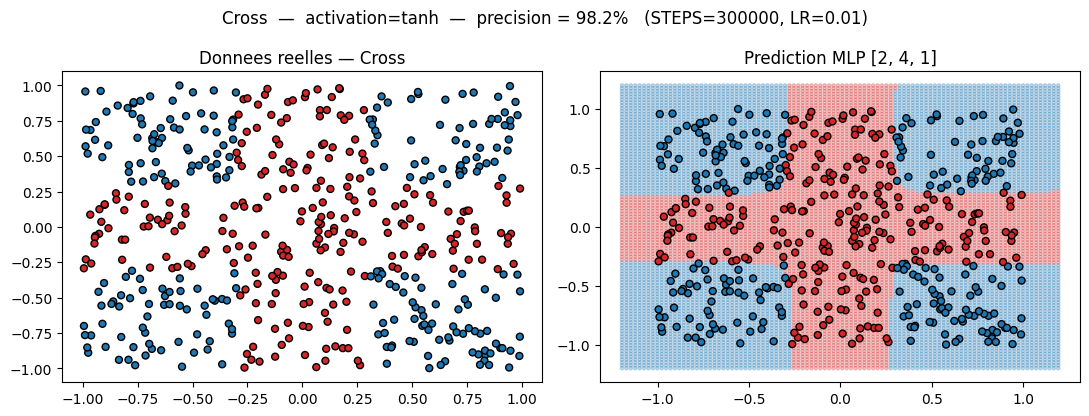

In [16]:
# ---- Cross ----  (Linear: KO / MLP (2,4,1): OK)
STEPS, LR, ARCH, ACTIV = 300_000, 0.01, [2, 4, 1], "tanh"
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])
montre_classif(X, Y, ARCH, STEPS, LR, "Cross", activation=ACTIV)

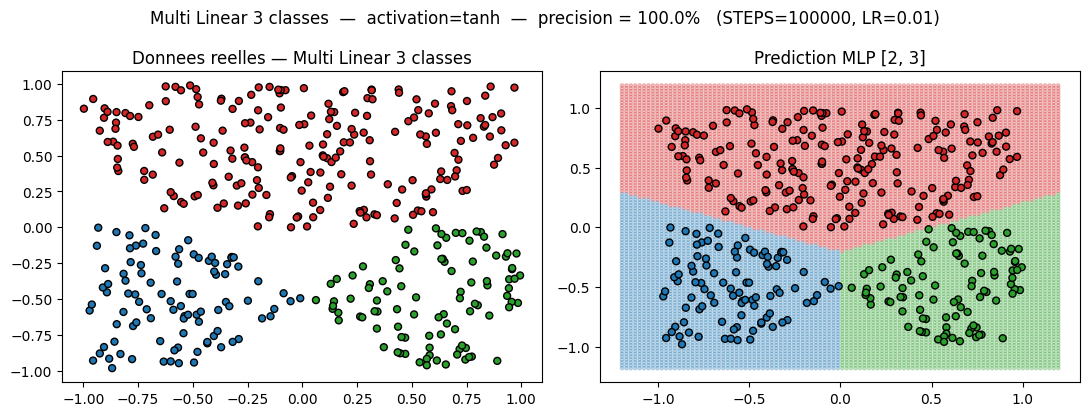

In [17]:
# ---- Multi Linear 3 classes ----  (MLP (2,3): OK)
STEPS, LR, ARCH, ACTIV = 100_000, 0.01, [2, 3], "tanh"
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1] for p in X])
garde = [not np.all(a == [-1, -1, -1]) for a in Y]
X, Y = X[garde], Y[garde]
montre_classif(X, Y, ARCH, STEPS, LR, "Multi Linear 3 classes", activation=ACTIV)

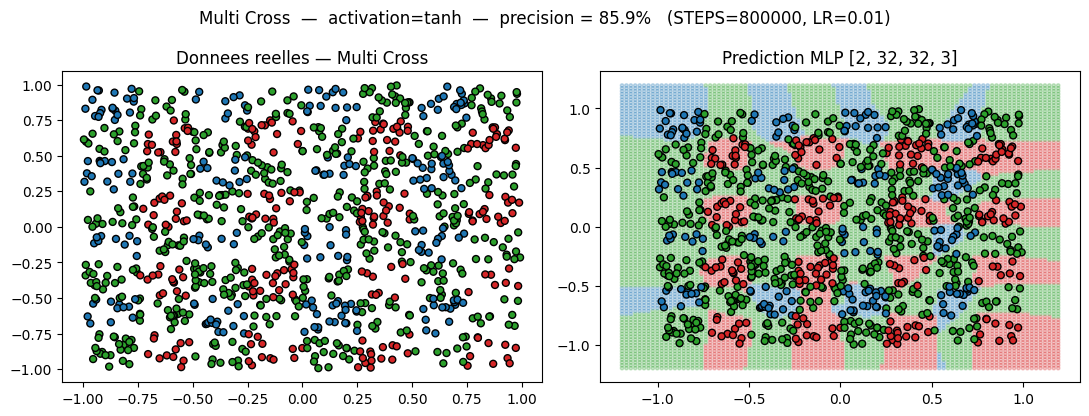

In [18]:
# ---- Multi Cross ----  (MLP (2,?,?,3): OK)  <- le plus dur
STEPS, LR, ARCH, ACTIV = 800_000, 0.01, [2, 32, 32, 3], "tanh"
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else
              [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else
              [-1, -1, 1] for p in X])
montre_classif(X, Y, ARCH, STEPS, LR, "Multi Cross", activation=ACTIV)

## Régression  (sortie linéaire)

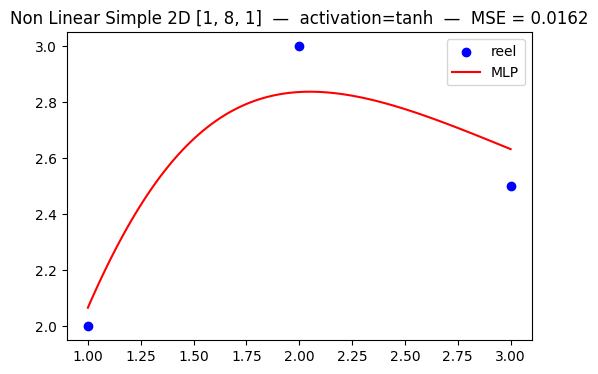

In [19]:
# ---- Non Linear Simple 2D ----  (MLP (1,?,1): OK)
STEPS, LR, ARCH, ACTIV = 100_000, 0.001, [1, 8, 1], "tanh"
X = np.array([[1], [2], [3]]); Y = np.array([2, 3, 2.5])
montre_reg(X, Y, ARCH, STEPS, LR, "Non Linear Simple 2D", activation=ACTIV)

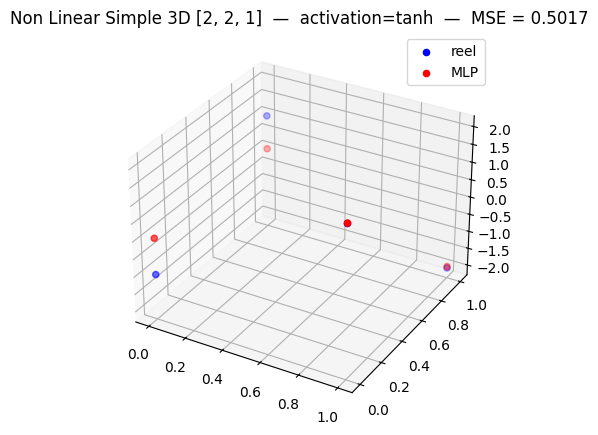

In [20]:
# ---- Non Linear Simple 3D ----  (MLP (2,2,1): OK)
STEPS, LR, ARCH, ACTIV = 200_000, 0.01, [2, 2, 1], "tanh"
X = np.array([[1, 0], [0, 1], [1, 1], [0, 0]]); Y = np.array([2, 1, -2, -1])
montre_reg(X, Y, ARCH, STEPS, LR, "Non Linear Simple 3D", activation=ACTIV)

## Comparaison des activations (pour le rapport)

On entraîne le **même** cas avec `tanh`, `sigmoid` et `relu`, côte à côte.
Change le cas ou les hyperparamètres pour générer les figures de ton rapport.

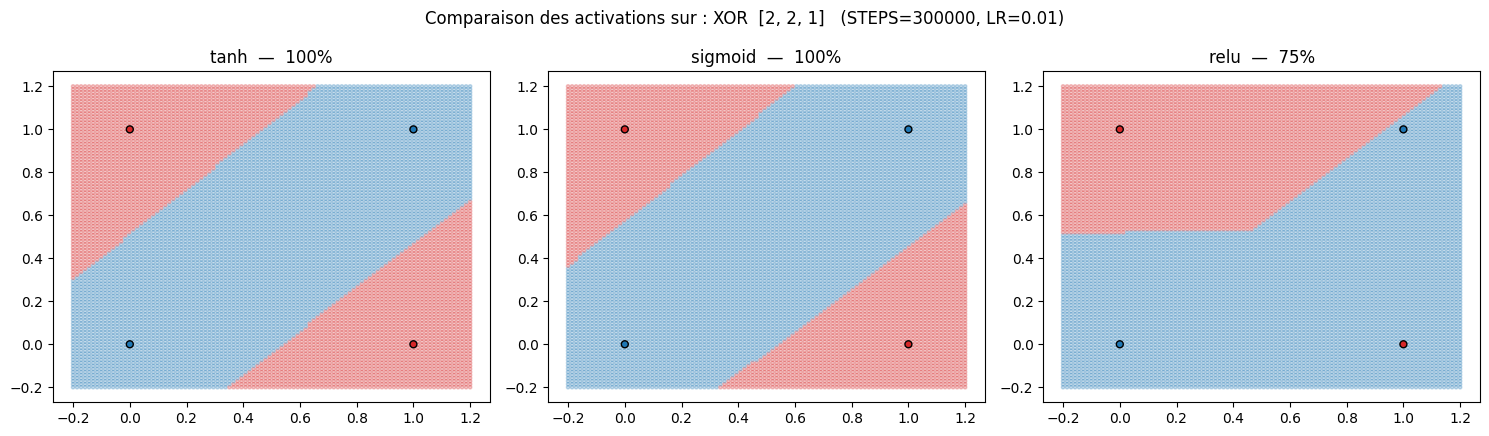

In [21]:
# ---- Comparaison sur XOR ----
STEPS, LR, ARCH = 300_000, 0.01, [2, 2, 1]
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])
compare_activations(X, Y, ARCH, STEPS, LR, "XOR")

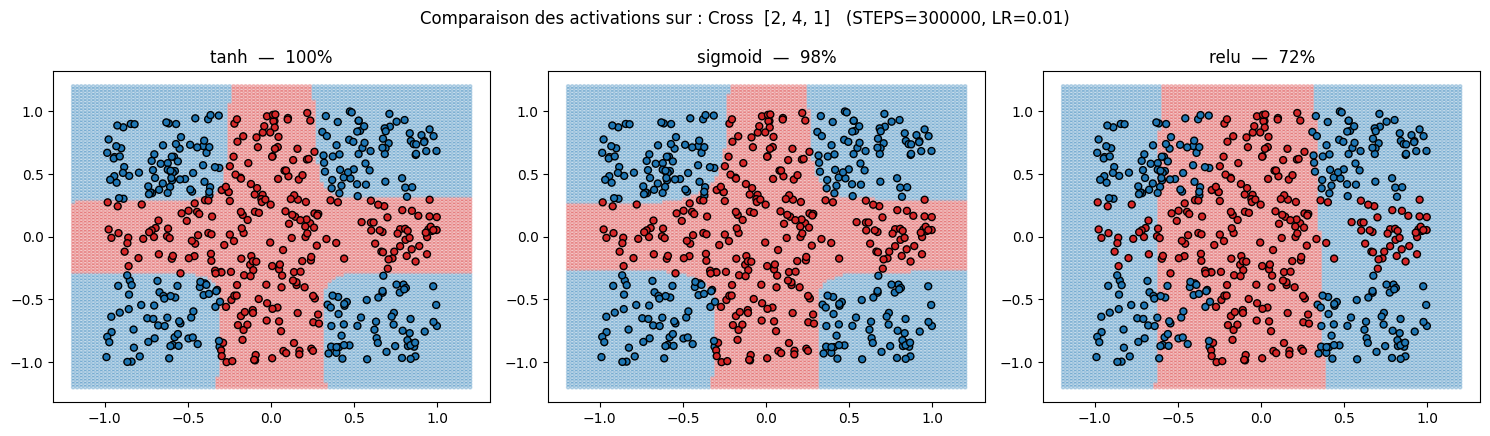

In [22]:
# ---- Comparaison sur Cross ----
STEPS, LR, ARCH = 300_000, 0.01, [2, 4, 1]
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])
compare_activations(X, Y, ARCH, STEPS, LR, "Cross")